# PINN 求解无解析解的非线性偏微分方程：一维 Burgers' Equation

在这个 Notebook 中，我们使用 PINN (物理信息神经网络) 来求解一维黏性 Burgers' 方程。这是一个包含非线性对流项和耗散项的经典流体力学 PDE，**它没有简单的初等函数解析解**，属于强非线性激波问题，是 PINN 论文中最经典的测试用例之一。

**偏微分方程 (Navier-Stokes 的一维形式)：**
$$ \frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} - \frac{0.01}{\pi} \frac{\partial^2 u}{\partial x^2} = 0 $$

求解区域：$t \in [0, 1], x \in [-1, 1]$

**边界与初始条件：**
- 初始条件 (初态波形): $u(x, 0) = -\sin(\pi x)$
- 边界条件 (无穷远边界约束): $u(-1, t) = u(1, t) = 0$

**验证方式：**
由于无解析解，我们使用布朗大学 Maziar Raissi 教授（PINN创始人）提供的高精度数值解数据集 `burgers_shock.mat` 作为我们的 **Ground Truth (公认真实结果)** 进行准确度评价。

In [3]:
import torch
import torch.nn as nn
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

torch.manual_seed(1234)

## 1. 神经网络与数据采样
这次我们的网络输入是双变量 `(x, t)`，输出仍然是目标标量 `u`。

In [4]:
class BurgersPINN(nn.Module):
    def __init__(self):
        super(BurgersPINN, self).__init__()
        # 采用 5 个隐藏层，每层 32 个节点
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x, t):
        # 将 x 和 t 拼起来作为输入 [batch_size, 2]
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)

## 2. 准备方程内配点 (Collocation Points) 和边界/初始数据点

In [5]:
# ---- 采样子函数 ----
N_f = 10000  # 物理防卫域配点数量

# 物理区域内均匀撒点
x_f = torch.FloatTensor(N_f, 1).uniform_(-1.0, 1.0).requires_grad_(True)
t_f = torch.FloatTensor(N_f, 1).uniform_(0.0, 1.0).requires_grad_(True)

# ---------------------
# 边界条件 (Boundary Conditions)
# 我们在 t in [0, 1] 随机生成边界上的时间点
N_b = 200
t_b = torch.FloatTensor(N_b, 1).uniform_(0.0, 1.0)
x_lb = torch.ones_like(t_b) * -1.0      # left boundary:  x = -1
x_rb = torch.ones_like(t_b) *  1.0      # right boundary: x = 1

# ---------------------
# 初始条件 (Initial Condition)
# 在 x in [-1, 1] 随机生成 t=0 时的空间点
N_0 = 300
x_0 = torch.FloatTensor(N_0, 1).uniform_(-1.0, 1.0)
t_0 = torch.zeros_like(x_0)             # t = 0
u_0 = -torch.sin(np.pi * x_0)           # 已知初始情况

## 3. 模型训练
因为使用了标准的 Adam 算法（没有上计算代价巨大的 L-BFGS），可能需要稍微多跑几步

In [6]:
model = BurgersPINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 3000
nu = 0.01 / np.pi

print("开始训练...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    
    # ---- 1. PDE 残差计算 ----
    u = model(x_f, t_f)
    
    u_x = torch.autograd.grad(u, x_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_f, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    
    # Burgers方程: u_t + u*u_x - nu*u_xx = 0
    f_pred = u_t + u * u_x - nu * u_xx
    loss_f = torch.mean(f_pred**2)
    
    # ---- 2. 初始条件 (IC) 损失 ----
    u_0_pred = model(x_0, t_0)
    loss_ic = torch.mean((u_0_pred - u_0)**2)
    
    # ---- 3. 边界条件 (BC) 损失 ----
    u_lb_pred = model(x_lb, t_b)
    u_rb_pred = model(x_rb, t_b)
    loss_bc = torch.mean((u_lb_pred - 0.0)**2) + torch.mean((u_rb_pred - 0.0)**2)
    
    # ---- 总损失 ----
    loss = loss_f + loss_ic + loss_bc
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch: {epoch} \t Loss: {loss.item():.5f} (PDE: {loss_f.item():.5f}, IC: {loss_ic.item():.5f}, BC: {loss_bc.item():.5f})")

print("训练完成！")

开始训练...
Epoch: 0 	 Loss: 0.52736 (PDE: 0.00002, IC: 0.51890, BC: 0.00844)
Epoch: 500 	 Loss: 0.11153 (PDE: 0.04008, IC: 0.06963, BC: 0.00182)
Epoch: 1000 	 Loss: 0.07853 (PDE: 0.03388, IC: 0.04421, BC: 0.00044)
Epoch: 1500 	 Loss: 0.04979 (PDE: 0.02465, IC: 0.02439, BC: 0.00075)
Epoch: 2000 	 Loss: 0.03017 (PDE: 0.01535, IC: 0.01451, BC: 0.00031)
Epoch: 2500 	 Loss: 0.02398 (PDE: 0.01290, IC: 0.01075, BC: 0.00034)
Epoch: 3000 	 Loss: 0.01734 (PDE: 0.00959, IC: 0.00743, BC: 0.00032)
训练完成！


## 4. 与权威数值解对比及绘图

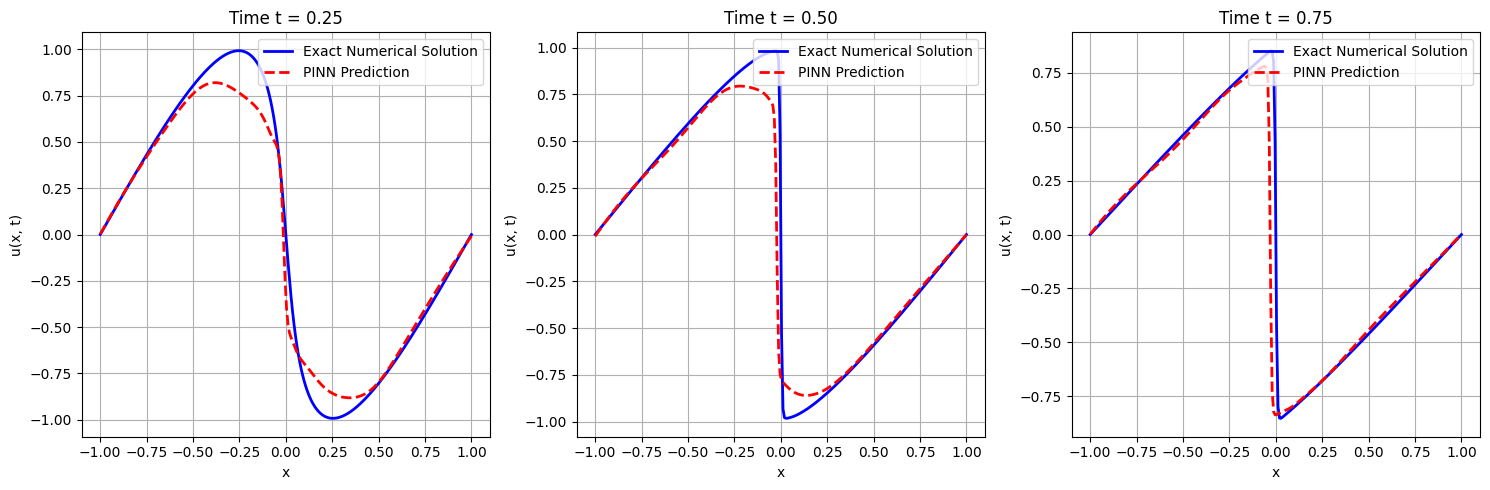

注意观察在 x=0 附近强烈的数值激波激波(Shock)！这是线性方法极难拟合但物理方程迫使PINN学到的重要特质。


In [16]:
# 读取高精度离散解 (Ground Truth)
try:
    data = scipy.io.loadmat('burgers_shock.mat')
    t_exact = data['t'].flatten()[:,None]  # shape: (100, 1)
    x_exact = data['x'].flatten()[:,None]  # shape: (256, 1)
    Exact_u = np.real(data['usol']).T      # shape: (100, 256) (T, X)
except FileNotFoundError:
    print("找不到 burgers_shock.mat 文件。")
    t_exact, x_exact, Exact_u = None, None, None

if Exact_u is not None:
    # 选择几个切片时间的真实解做对比，比如 t=0.25, t=0.50, t=0.75
    # t_exact 从 0 到 0.99，一共 100 个点，所以索引大概在 25, 50, 75
    idx_list = [25, 50, 75]
    
    model.eval()
    x_tensor = torch.FloatTensor(x_exact)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, idx in enumerate(idx_list):
        t_val = t_exact[idx][0]
        t_tensor = torch.ones_like(x_tensor) * t_val
        
        with torch.no_grad():
            u_pred = model(x_tensor, t_tensor).numpy().flatten()
        
        axes[i].plot(x_exact.flatten(), Exact_u[idx, :], 'b-', linewidth=2, label='Exact Numerical Solution')
        axes[i].plot(x_exact.flatten(), u_pred, 'r--', linewidth=2, label='PINN Prediction')
        axes[i].set_title(f"Time t = {t_val:.2f}")
        axes[i].set_xlabel("x")
        axes[i].set_ylabel("u(x, t)")
        axes[i].legend(loc='upper right')
        axes[i].grid(True)
        
    plt.tight_layout()
    plt.show()
    
    print("注意观察在 x=0 附近强烈的数值激波激波(Shock)！这是线性方法极难拟合但物理方程迫使PINN学到的重要特质。")